# 1.3 — Health Gain Exploration & Bias Analysis

## What is this notebook about?

This notebook explores **health gain** for NHS Knee Replacement patients.

| Term | Definition |
|------|-----------|
| **OKS Pre Score** | Oxford Knee Score before surgery (0 = worst, 48 = best) |
| **OKS Post Score** | Oxford Knee Score after surgery |
| **Health Gain** | Post Score − Pre Score |
| **Benefit** (0) | Health Gain > 7 — the patient improved meaningfully |
| **No Benefit** (1) | Health Gain ≤ 7 — minimal or no improvement |

A threshold of **7 points** is used because the minimum clinically important difference (MCID) for OKS is widely accepted as around 7.

**Key questions:**
1. How is the data split between Benefit and No Benefit? (class bias)
2. What does the health gain distribution look like?
3. Does age band or gender influence outcomes?
4. Which pre-op features correlate with health gain?

In [19]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Consistent visual style ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        120,
    "figure.facecolor":  "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "axes.axisbelow":    True,   # gridlines rendered behind bars/lines
    "grid.color":        "#e0e0e0",
    "grid.linewidth":    0.6,
    "font.size":         11,
})

# ── Color palette — change hex values here to update all charts at once ──────
BENEFIT    = "#3A7D44"   # label 0 — green  = good outcome
NO_BENEFIT = "#C0392B"   # label 1 — red    = flag / poor outcome
THRESH     = "#E67E22"   # threshold line   — amber, distinct from both

pd.set_option("display.float_format", "{:.2f}".format)
print("Libraries loaded.")

Libraries loaded.


## Load Data

In [20]:
from pathlib import Path

DATA_PATH = Path("./data/interim/1.1-Reduced.parquet")
df = pl.read_parquet(DATA_PATH)

PRE_COL  = "Knee Replacement Pre-Op Q Score"
POST_COL = "Knee Replacement Post-Op Q Score"

print(f"Rows   : {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nPre-Op Score  — nulls: {df[PRE_COL].null_count():,}  range: [{df[PRE_COL].min()}, {df[PRE_COL].max()}]")
print(f"Post-Op Score — nulls: {df[POST_COL].null_count():,}  range: [{df[POST_COL].min()}, {df[POST_COL].max()}]")

Rows   : 139,236
Columns: 82

Pre-Op Score  — nulls: 1,669  range: [0.0, 48.0]
Post-Op Score — nulls: 2,579  range: [0.0, 48.0]


---
## Section 1 — Compute Health Gain & Patient Categorisation

**Health Gain** = OKS Post Score − OKS Pre Score

- Positive value → the patient improved after surgery
- Negative value → the patient's score got worse

**Classification threshold = 7 points** (minimum clinically important difference)

| Label | Meaning | Condition |
|-------|---------|-----------|
| **0 — Benefit** | Meaningful improvement | Health Gain > 7 |
| **1 — No Benefit** | Little or no improvement | Health Gain ≤ 7 |

Patients where either score is missing are kept with a null health gain (they will be excluded from charts that require the value).

In [21]:
THRESHOLD = 7

df = df.with_columns([
    # Health gain: post minus pre (null if either score is missing)
    (pl.col(POST_COL) - pl.col(PRE_COL)).alias("Health Gain"),
])

df = df.with_columns([
    # Binary label: 0 = benefit (gain > 7), 1 = no benefit (gain <= 7)
    pl.when(pl.col("Health Gain") > THRESHOLD)
      .then(pl.lit(0))
      .when(pl.col("Health Gain").is_null())
      .then(pl.lit(None).cast(pl.Int8))
      .otherwise(pl.lit(1))
      .cast(pl.Int8)
      .alias("Benefit Label"),
])

# Quick summary
total       = df.shape[0]
valid       = df["Health Gain"].drop_nulls().len()
n_benefit   = int((df["Benefit Label"] == 0).sum())
n_no_benefit= int((df["Benefit Label"] == 1).sum())
n_null      = df["Benefit Label"].null_count()

print(f"Total patients        : {total:>8,}")
print(f"Valid health gain     : {valid:>8,}  ({100*valid/total:.1f}%)")
print(f"  Label 0 — Benefit   : {n_benefit:>8,}  ({100*n_benefit/valid:.1f}%)")
print(f"  Label 1 — No Benefit: {n_no_benefit:>8,}  ({100*n_no_benefit/valid:.1f}%)")
print(f"  Missing (excluded)  : {n_null:>8,}  ({100*n_null/total:.1f}%)")
print(f"\nHealth Gain stats (valid rows):")
print(df["Health Gain"].drop_nulls().describe())

Total patients        :  139,236
Valid health gain     :  135,051  (97.0%)
  Label 0 — Benefit   :  111,953  (82.9%)
  Label 1 — No Benefit:   23,098  (17.1%)
  Missing (excluded)  :    4,185  (3.0%)

Health Gain stats (valid rows):
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 135051.0  │
│ null_count ┆ 0.0       │
│ mean       ┆ 16.889006 │
│ std        ┆ 9.85862   │
│ min        ┆ -37.0     │
│ 25%        ┆ 10.0      │
│ 50%        ┆ 17.0      │
│ 75%        ┆ 24.0      │
│ max        ┆ 47.0      │
└────────────┴───────────┘


---
## Section 2 — Target Class Distribution (Bias Check)

A balanced dataset has roughly **50% in each class**.  
If one class dominates, the model will be biased toward predicting that class.

This chart shows the raw patient count and percentage for each label.

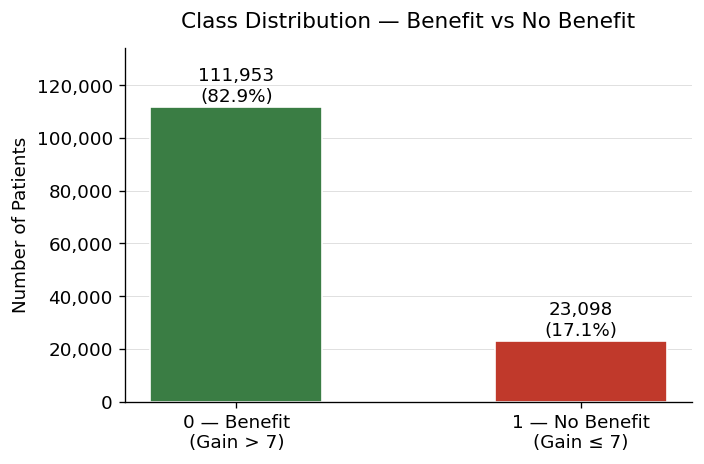


Imbalance ratio  : 4.85  (Benefit : No-Benefit)
⚠  Dataset is imbalanced — the Benefit class is the majority.


In [22]:
labels  = ["0 — Benefit\n(Gain > 7)", "1 — No Benefit\n(Gain ≤ 7)"]
counts  = [n_benefit, n_no_benefit]
colors  = [BENEFIT, NO_BENEFIT]
pcts    = [100 * c / (n_benefit + n_no_benefit) for c in counts]

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(labels, counts, color=colors, width=0.5, edgecolor="white")

# Annotate each bar with count + percentage
for bar, count, pct in zip(bars, counts, pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{count:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11
    )

ax.set_title("Class Distribution — Benefit vs No Benefit", fontsize=13, pad=12)
ax.set_ylabel("Number of Patients")
ax.set_ylim(0, max(counts) * 1.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

ratio = n_benefit / n_no_benefit
print(f"\nImbalance ratio  : {ratio:.2f}  (Benefit : No-Benefit)")
if ratio > 1.5:
    print("⚠  Dataset is imbalanced — the Benefit class is the majority.")

---
## Section 3 — OKS Pre & Post Score Distributions

Comparing the score distributions **before and after surgery** tells us:
- Whether most patients started with low (bad) scores — confirming they genuinely needed surgery
- Whether scores shifted upward after surgery — confirming the procedure helped

Each histogram is plotted separately so the shapes are easy to compare.

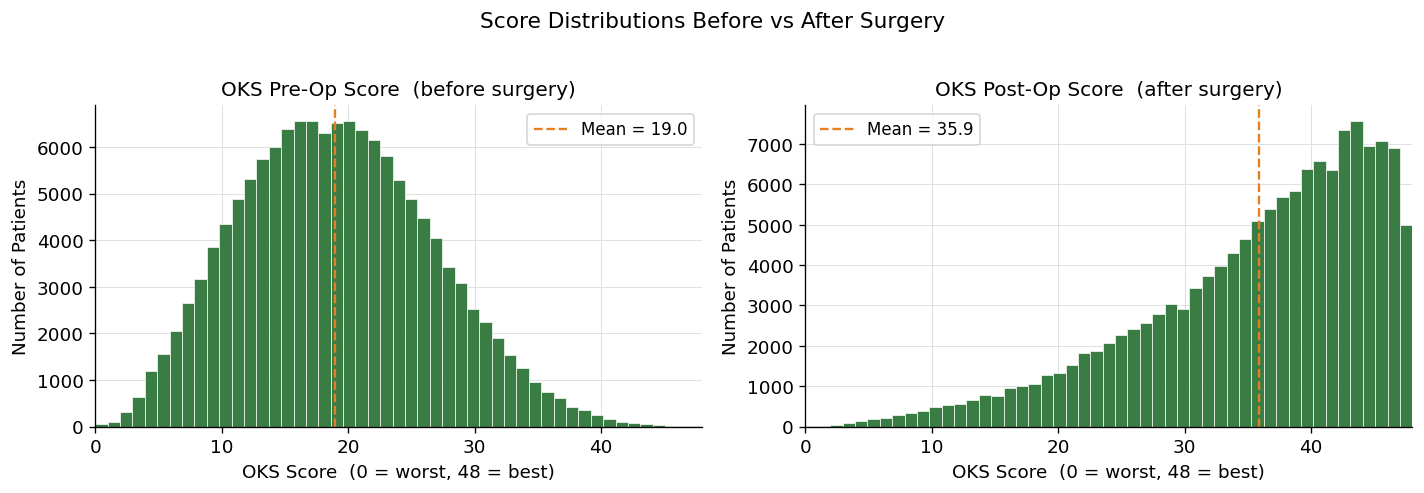

In [23]:
pre_vals  = df[PRE_COL].drop_nulls().to_numpy()
post_vals = df[POST_COL].drop_nulls().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, vals, title in zip(
    axes,
    [pre_vals, post_vals],
    ["OKS Pre-Op Score  (before surgery)", "OKS Post-Op Score  (after surgery)"]
):
    ax.hist(vals, bins=49, range=(0, 48), color=BENEFIT, edgecolor="white", linewidth=0.4)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("OKS Score  (0 = worst, 48 = best)")
    ax.set_ylabel("Number of Patients")
    ax.set_xlim(0, 48)

    mean_val = vals.mean()
    ax.axvline(mean_val, color=THRESH, linestyle="--", linewidth=1.4, label=f"Mean = {mean_val:.1f}")
    ax.legend(fontsize=10)

fig.suptitle("Score Distributions Before vs After Surgery", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 4 — Health Gain Distribution

This histogram shows how much each patient improved.  
The **red dashed line** at x = 7 is the classification threshold.

- Everything to the **right** of the line → **Benefit** (label 0)
- Everything to the **left** of the line → **No Benefit** (label 1)

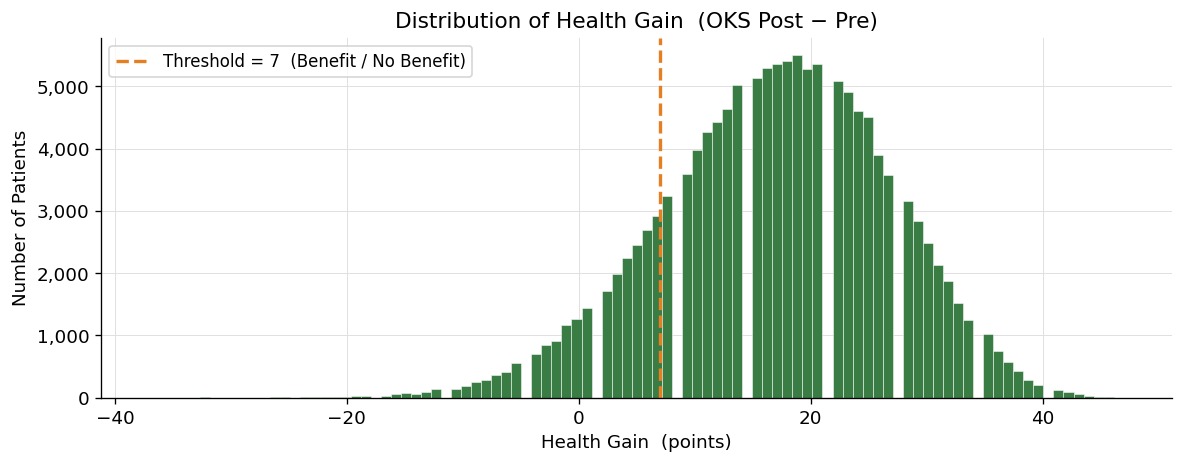

Median health gain : 17.0 points
Mean health gain   : 16.9 points
% patients with gain > 7 : 82.9%


In [24]:
gain_vals = df["Health Gain"].drop_nulls().to_numpy()

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(gain_vals, bins=97, color=BENEFIT, edgecolor="white", linewidth=0.3)

ax.axvline(THRESHOLD, color=THRESH, linestyle="--", linewidth=2,
           label=f"Threshold = {THRESHOLD}  (Benefit / No Benefit)")

ax.set_title("Distribution of Health Gain  (OKS Post − Pre)", fontsize=13)
ax.set_xlabel("Health Gain  (points)")
ax.set_ylabel("Number of Patients")
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

print(f"Median health gain : {np.median(gain_vals):.1f} points")
print(f"Mean health gain   : {np.mean(gain_vals):.1f} points")
print(f"% patients with gain > 7 : {100*(gain_vals > 7).mean():.1f}%")

---
## Section 5 — Health Gain by Age Band

Does the patient's age group affect how much they improve?

Each bar shows the **average health gain** for that age band.  
The dashed line marks the threshold — bars above it indicate that the average patient in that group benefited.

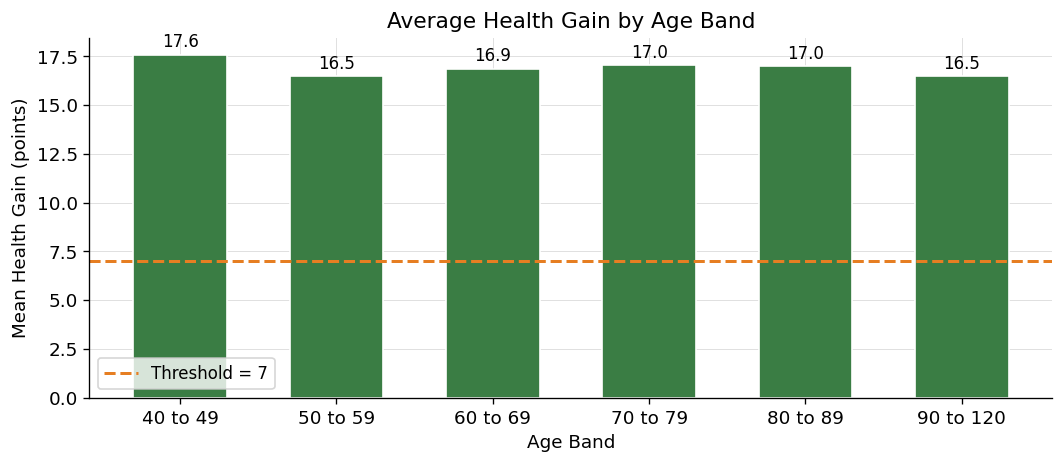

 Age Band  Mean Gain  Median Gain  Count
 40 to 49      17.57        19.00    247
 50 to 59      16.48        17.00  13007
 60 to 69      16.85        17.00  44266
 70 to 79      17.03        17.00  53210
 80 to 89      16.97        17.00  15171
90 to 120      16.48        19.00     23


In [25]:
AGE_COL = "Age Band"

# Ordered age bands present in the data
AGE_ORDER = ["40 to 49", "50 to 59", "60 to 69", "70 to 79", "80 to 89", "90 to 120"]

age_gain = (
    df.filter(pl.col("Health Gain").is_not_null() & pl.col(AGE_COL).is_not_null())
    .group_by(AGE_COL)
    .agg([
        pl.col("Health Gain").mean().alias("Mean Gain"),
        pl.col("Health Gain").median().alias("Median Gain"),
        pl.len().alias("Count"),
    ])
    .to_pandas()
    .set_index(AGE_COL)
    .reindex(AGE_ORDER)
    .dropna()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(age_gain[AGE_COL], age_gain["Mean Gain"], color=BENEFIT, edgecolor="white", width=0.6)

ax.axhline(THRESHOLD, color=THRESH, linestyle="--", linewidth=1.8,
           label=f"Threshold = {THRESHOLD}")

# Annotate bars
for _, row in age_gain.iterrows():
    ax.text(row[AGE_COL], row["Mean Gain"] + 0.2,
            f"{row['Mean Gain']:.1f}", ha="center", va="bottom", fontsize=10)

ax.set_title("Average Health Gain by Age Band", fontsize=13)
ax.set_xlabel("Age Band")
ax.set_ylabel("Mean Health Gain (points)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(age_gain[[AGE_COL, "Mean Gain", "Median Gain", "Count"]].to_string(index=False))

---
## Section 6 — Health Gain by Gender

Gender is coded as **1 = Male, 2 = Female** in this dataset.  
The box plot shows the full spread of health gains — median line, interquartile range, and whiskers.

This lets you see whether one gender tends to benefit more than the other.

C:\Users\mittall\AppData\Local\Temp\ipykernel_36508\1095370597.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


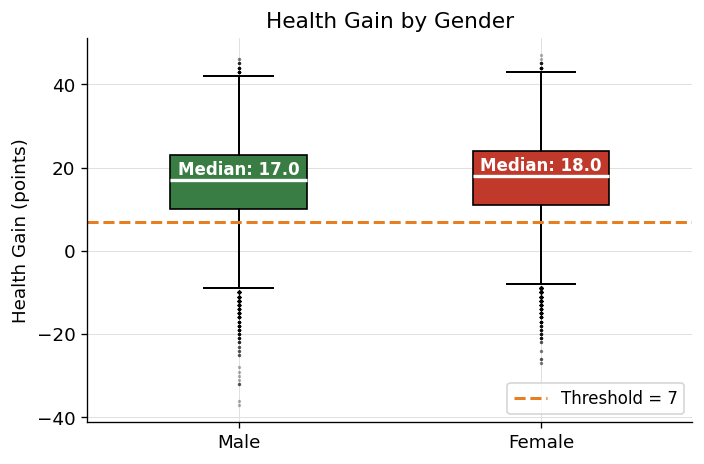

Male      n=54,137  mean=16.4  median=17.0  % benefit=81.9%
Female    n=71,787  mean=17.3  median=18.0  % benefit=83.8%


In [26]:
GENDER_COL = "Gender"

# Map numeric codes to readable labels
df_gender = (
    df.filter(pl.col("Health Gain").is_not_null() & pl.col(GENDER_COL).is_not_null())
    .with_columns(
        pl.col(GENDER_COL).cast(pl.Utf8)
          .map_elements(lambda v: "Male" if v == "1" else ("Female" if v == "2" else "Other"),
                        return_dtype=pl.Utf8)
          .alias("Gender Label")
    )
)

groups = ["Male", "Female"]
data_by_gender = [
    df_gender.filter(pl.col("Gender Label") == g)["Health Gain"].to_numpy()
    for g in groups
]

fig, ax = plt.subplots(figsize=(6, 4))

bp = ax.boxplot(
    data_by_gender,
    labels=groups,
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker=".", markersize=2, alpha=0.3, color=NO_BENEFIT),
)

for patch, color in zip(bp["boxes"], [BENEFIT, NO_BENEFIT]):
    patch.set_facecolor(color)

ax.axhline(THRESHOLD, color=THRESH, linestyle="--", linewidth=1.8,
           label=f"Threshold = {THRESHOLD}")

# Annotate medians
for i, d in enumerate(data_by_gender, start=1):
    med = np.median(d)
    ax.text(i, med + 0.3, f"Median: {med:.1f}", ha="center", va="bottom", fontsize=10, color="white",
            fontweight="bold")

ax.set_title("Health Gain by Gender", fontsize=13)
ax.set_ylabel("Health Gain (points)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Summary table
for g, d in zip(groups, data_by_gender):
    pct_benefit = 100 * (d > THRESHOLD).mean()
    print(f"{g:8s}  n={len(d):>6,}  mean={d.mean():.1f}  median={np.median(d):.1f}  % benefit={pct_benefit:.1f}%")

---
## Section 7 — Pre-Op Score vs Health Gain

Patients who start with a **very low pre-op score** (worst condition) have more room to improve.  
Patients who start with a **high pre-op score** may already be near their ceiling.

This scatter plot reveals whether the starting condition predicts the health gain,  
which is a known phenomenon called **regression to the mean**.

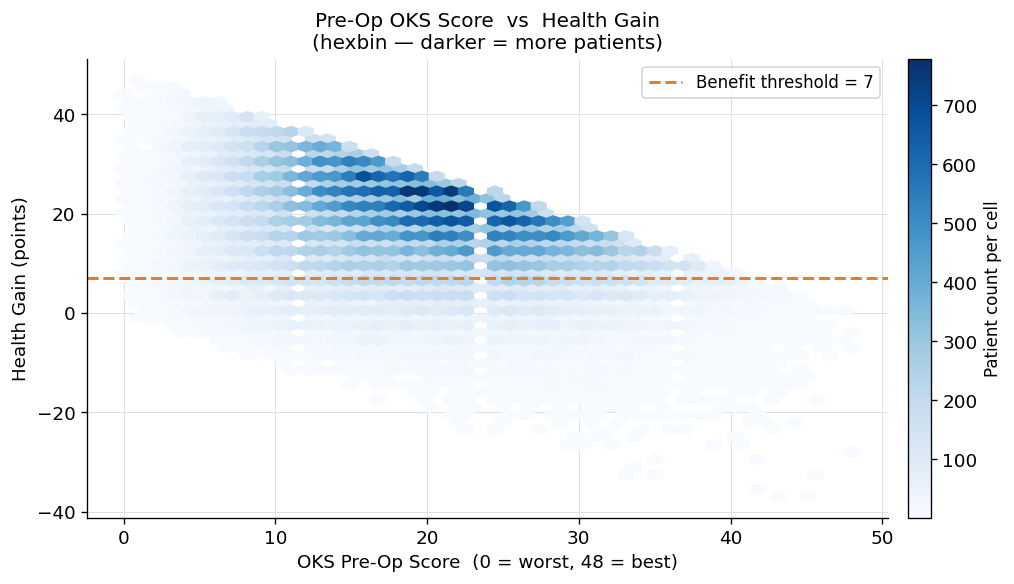

Pearson correlation (Pre-Op Score vs Health Gain): -0.442


In [27]:
df_scatter = (
    df.filter(pl.col("Health Gain").is_not_null())
    .select([PRE_COL, "Health Gain"])
    .to_pandas()
)

# Use a 2D hexbin to avoid overplotting (dataset is large)
fig, ax = plt.subplots(figsize=(9, 5))

hb = ax.hexbin(
    df_scatter[PRE_COL],
    df_scatter["Health Gain"],
    gridsize=50,
    cmap="Blues",
    mincnt=1,
)

ax.axhline(THRESHOLD, color=THRESH, linestyle="--", linewidth=1.8,
           label=f"Benefit threshold = {THRESHOLD}")

cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label("Patient count per cell", fontsize=10)

ax.set_title("Pre-Op OKS Score  vs  Health Gain\n(hexbin — darker = more patients)", fontsize=12)
ax.set_xlabel(f"OKS Pre-Op Score  (0 = worst, 48 = best)")
ax.set_ylabel("Health Gain (points)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Correlation
corr = df_scatter[PRE_COL].corr(df_scatter["Health Gain"])
print(f"Pearson correlation (Pre-Op Score vs Health Gain): {corr:.3f}")

---
## Section 8 — Benefit Rate by Age Band

Rather than looking at average health gain, this chart shows **what percentage of patients in each age group benefited** (label = 0).

This is a direct answer to the question: *"Does age influence whether surgery is worth it?"*

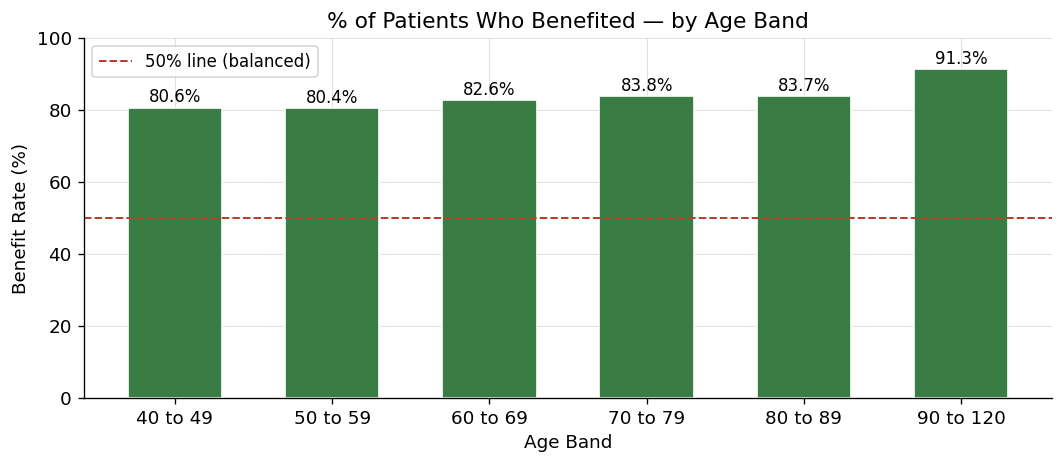

In [28]:
benefit_by_age = (
    df.filter(pl.col("Benefit Label").is_not_null() & pl.col(AGE_COL).is_not_null())
    .group_by(AGE_COL)
    .agg([
        (pl.col("Benefit Label") == 0).sum().alias("n_benefit"),
        pl.len().alias("n_total"),
    ])
    .with_columns(
        (100 * pl.col("n_benefit") / pl.col("n_total")).alias("Benefit Rate %")
    )
    .to_pandas()
    .set_index(AGE_COL)
    .reindex(AGE_ORDER)
    .dropna()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(benefit_by_age[AGE_COL], benefit_by_age["Benefit Rate %"],
       color=BENEFIT, edgecolor="white", width=0.6)

ax.axhline(50, color=NO_BENEFIT, linestyle="--", linewidth=1.2, label="50% line (balanced)")

for _, row in benefit_by_age.iterrows():
    ax.text(row[AGE_COL], row["Benefit Rate %"] + 0.5,
            f"{row['Benefit Rate %']:.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_title("% of Patients Who Benefited — by Age Band", fontsize=13)
ax.set_xlabel("Age Band")
ax.set_ylabel("Benefit Rate (%)")
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Section 9 — Year-Over-Year Benefit Rate

Does the proportion of patients benefiting change across the three data collection years?  
A consistent rate confirms the label is stable; a trend might indicate changes in patient selection or reporting.

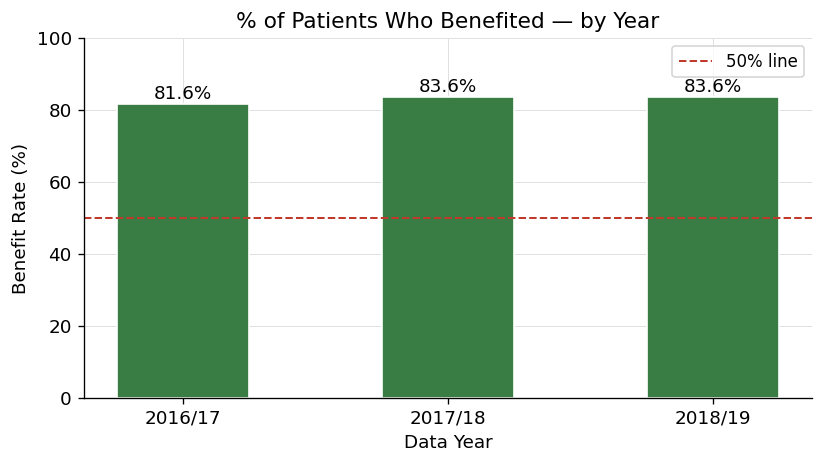

   Year  n_benefit  n_no_benefit  n_total  Benefit Rate %
2016/17      37909          8529    46438           81.63
2017/18      37041          7290    44331           83.56
2018/19      37003          7279    44282           83.56


In [29]:
YEAR_COL = "Year"
year_order = ["2016/17", "2017/18", "2018/19"]

benefit_by_year = (
    df.filter(pl.col("Benefit Label").is_not_null() & pl.col(YEAR_COL).is_not_null())
    .group_by(YEAR_COL)
    .agg([
        (pl.col("Benefit Label") == 0).sum().alias("n_benefit"),
        (pl.col("Benefit Label") == 1).sum().alias("n_no_benefit"),
        pl.len().alias("n_total"),
    ])
    .with_columns(
        (100 * pl.col("n_benefit") / pl.col("n_total")).alias("Benefit Rate %")
    )
    .to_pandas()
    .set_index(YEAR_COL)
    .reindex(year_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(benefit_by_year[YEAR_COL], benefit_by_year["Benefit Rate %"],
       color=BENEFIT, edgecolor="white", width=0.5)

ax.axhline(50, color=NO_BENEFIT, linestyle="--", linewidth=1.2, label="50% line")

for _, row in benefit_by_year.iterrows():
    ax.text(row[YEAR_COL], row["Benefit Rate %"] + 0.4,
            f"{row['Benefit Rate %']:.1f}%", ha="center", va="bottom", fontsize=11)

ax.set_title("% of Patients Who Benefited — by Year", fontsize=13)
ax.set_xlabel("Data Year")
ax.set_ylabel("Benefit Rate (%)")
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(benefit_by_year[[YEAR_COL, "n_benefit", "n_no_benefit", "n_total", "Benefit Rate %"]].to_string(index=False))

---
## Section 10 — Correlation Heatmap

How strongly do numerical features correlate with each other and with **Health Gain**?

- Values close to **+1** → strong positive relationship
- Values close to **−1** → strong negative relationship
- Values close to **0** → little to no linear relationship

A single-colour (blue) palette keeps it easy to read.

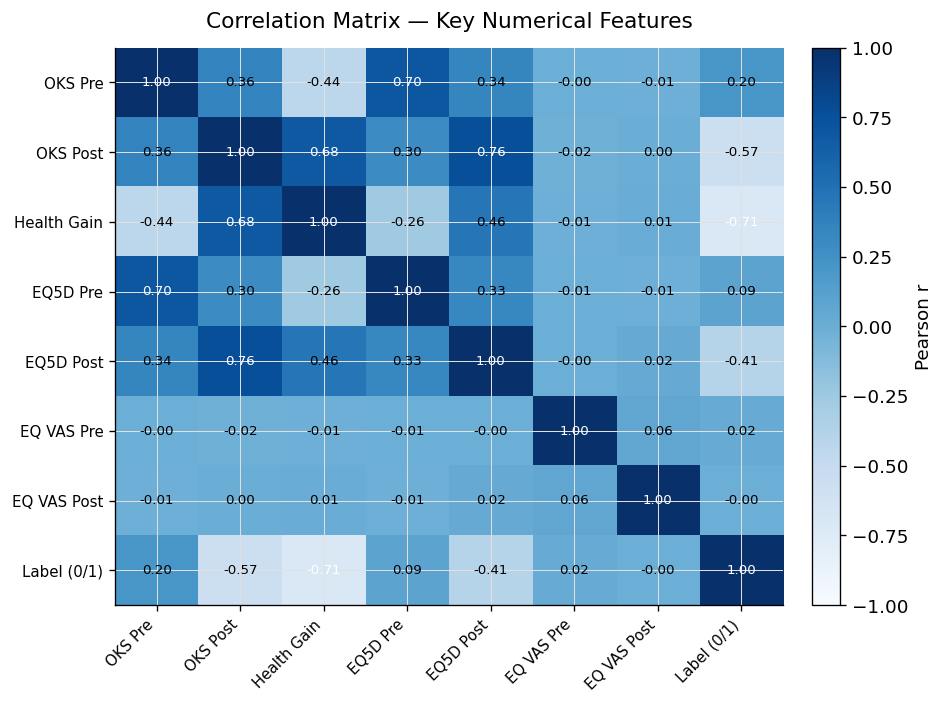

In [30]:
CORR_COLS = [
    "Knee Replacement Pre-Op Q Score",
    "Knee Replacement Post-Op Q Score",
    "Health Gain",
    "Pre-Op Q EQ5D Index",
    "Post-Op Q EQ5D Index",
    "Pre-Op Q EQ VAS",
    "Post-Op Q EQ VAS",
    "Benefit Label",
]

# Keep only columns that exist in the dataframe
CORR_COLS = [c for c in CORR_COLS if c in df.columns]

corr_pd = (
    df.select(CORR_COLS)
    .to_pandas()
    .astype(float)
    .corr()
)

# Short display names
short_names = {
    "Knee Replacement Pre-Op Q Score":  "OKS Pre",
    "Knee Replacement Post-Op Q Score": "OKS Post",
    "Health Gain":                       "Health Gain",
    "Pre-Op Q EQ5D Index":               "EQ5D Pre",
    "Post-Op Q EQ5D Index":              "EQ5D Post",
    "Pre-Op Q EQ VAS":                   "EQ VAS Pre",
    "Post-Op Q EQ VAS":                  "EQ VAS Post",
    "Benefit Label":                     "Label (0/1)",
}
corr_pd = corr_pd.rename(index=short_names, columns=short_names)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(corr_pd.values, cmap="Blues", vmin=-1, vmax=1, aspect="auto")

# Tick labels
ax.set_xticks(range(len(corr_pd.columns)))
ax.set_yticks(range(len(corr_pd.index)))
ax.set_xticklabels(corr_pd.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_pd.index, fontsize=9)

# Annotate cells
for i in range(len(corr_pd)):
    for j in range(len(corr_pd.columns)):
        val = corr_pd.values[i, j]
        text_color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=8, color=text_color)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
ax.set_title("Correlation Matrix — Key Numerical Features", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

---
## Section 11 — Missing Data Overview

Before modelling, we need to understand which columns have missing values and how severe the problem is.  
Missing data in the OKS scores directly reduces the labelled set available for training.

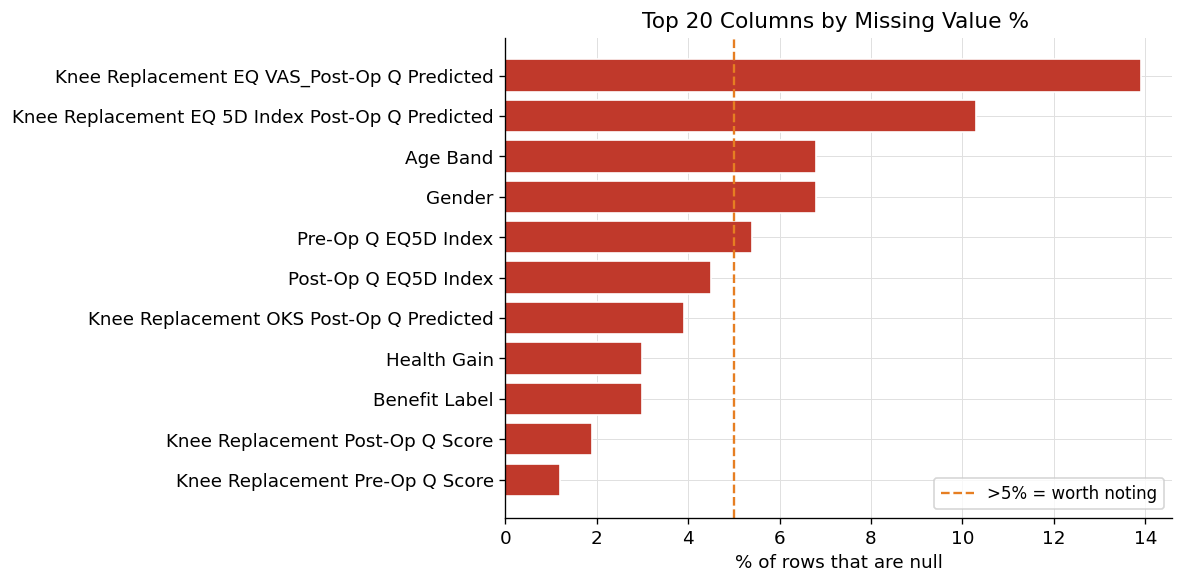


Total rows: 139,236
Columns with any missing: 11

                                          Column  Null Count  Null %
     Knee Replacement EQ VAS_Post-Op Q Predicted       19423   13.90
Knee Replacement EQ 5D Index Post-Op Q Predicted       14322   10.30
                                        Age Band        9402    6.80
                                          Gender        9402    6.80
                             Pre-Op Q EQ5D Index        7500    5.40
                            Post-Op Q EQ5D Index        6274    4.50
        Knee Replacement OKS Post-Op Q Predicted        5381    3.90
                                     Health Gain        4185    3.00
                                   Benefit Label        4185    3.00
                Knee Replacement Post-Op Q Score        2579    1.90
                 Knee Replacement Pre-Op Q Score        1669    1.20


In [31]:
n_total = df.shape[0]

null_counts = (
    df.null_count()
    .transpose(include_header=True, header_name="Column", column_names=["Null Count"])
    .with_columns(
        (100 * pl.col("Null Count") / n_total).round(1).alias("Null %")
    )
    .filter(pl.col("Null Count") > 0)
    .sort("Null %", descending=True)
    .to_pandas()
)

# Show only top 20 columns with most missing values
top_missing = null_counts.head(20)

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(top_missing["Column"], top_missing["Null %"], color=NO_BENEFIT, edgecolor="white")

ax.set_title("Top 20 Columns by Missing Value % ", fontsize=13)
ax.set_xlabel("% of rows that are null")
ax.set_ylabel("")
ax.invert_yaxis()
ax.axvline(5, color=THRESH, linestyle="--", linewidth=1.4, label=">5% = worth noting")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nTotal rows: {n_total:,}")
print(f"Columns with any missing: {len(null_counts)}")
print()
print(null_counts.head(20).to_string(index=False))

---
## Section 12 — Save Enriched Dataset

Save the dataframe with the **Health Gain** and **Benefit Label** columns added,  
so the next notebook (data preparation) can use this as its starting point.

In [32]:
OUT_PATH = Path("./data/interim/1.3-Health-Gain.parquet")
df.write_parquet(OUT_PATH, compression="gzip")
print(f"Saved  : {OUT_PATH}")
print(f"Shape  : {df.shape}")
print(f"New columns added: 'Health Gain', 'Benefit Label'")

Saved  : data\interim\1.3-Health-Gain.parquet
Shape  : (139236, 84)
New columns added: 'Health Gain', 'Benefit Label'
